

---

### 1. What fundamental problem does the Attention Mechanism address in the basic Encoder-Decoder architecture?

The Attention Mechanism addresses the inherent limitation of the basic Encoder-Decoder architecture to effectively handle **long sentences** ``. In this traditional setup, the encoder is tasked with processing an entire input sentence and generating a **single summary vector (or representation)** ``. This vector is then passed to the decoder to produce the output sentence ``. The core problem arises because this single, fixed-length vector struggles to **accurately summarize very long sentences**, placing an **unnecessary and heavy burden** on the encoder ``. As humans, we also find it difficult to read a very long sentence once, memorize it, and then translate it entirely ``.

---

### 2. What are the two main problems identified in the standard Encoder-Decoder architecture that necessitated the Attention Mechanism?

The standard Encoder-Decoder architecture presents two primary issues:

*   **Encoder-side Problem: Overloaded Summary Vector**
    *   The encoder attempts to compress **all information** from a potentially long input sentence into a **single, fixed-size summary vector** ``. For sentences **longer than approximately 25 words**, this summary vector becomes **overloaded**, making it very difficult to retain all necessary context ``. This puts immense pressure on the encoder ``.
*   **Decoder-side Problem: Static Representation**
    *   The decoder receives this **static, unchanging summary representation** at every single time step during output generation ``. However, for translating individual words or short phrases, the decoder **does not need the entire input sentence** ``. It would be much more efficient and accurate if the decoder could **dynamically focus on specific, relevant parts** of the input sentence at each step, rather than being given the full, static context ``.

---

### 3. What is the core conceptual idea behind the Attention Mechanism, using a human analogy?

The core conceptual idea behind the Attention Mechanism is inspired by how **human beings translate long texts** ``. When humans translate, they do not memorize the entire sentence at once ``. Instead, as they move through the sentence, their brains and eyes create an **"attention span" or "attention region"** ``. This region defines where their focus is currently ``. As they progress, this focus shifts ``. This means they perform **"on-the-go" translation**, capturing the context around the current point of interest ``. The Attention Mechanism aims to introduce this **dynamic, selective focusing capability** into the neural network architecture ``.

---

### 4. How does the Attention Mechanism change the input to the decoder compared to a vanilla Encoder-Decoder model?

In a **vanilla Encoder-Decoder architecture**, at any particular time step `i` of the decoder, two pieces of input are typically provided ``:
1.  **`y_i-1`**: The previously generated target word (or the correct target word via teacher forcing) ``.
2.  **`s_i-1`**: The previous hidden state of the decoder ``.

With the **Attention Mechanism**, a **third, crucial piece of information** is passed to the decoder at every time step `i` ``. This new input is called the **"Attention Input" or "Context Vector" (`c_i`)** ``. This `c_i` dynamically informs the decoder about **which parts of the encoder's output (hidden states) are most relevant** for generating the current target word ``.

---

### 5. What is the "Attention Input" or "Context Vector" (`c_i`) in the Attention Mechanism, and what are its key characteristics?

The "Attention Input" or "Context Vector" (`c_i`) is a **vector** that serves the purpose of telling the decoder **which specific encoder hidden state(s) are most useful** for producing the current target word ``.

Key characteristics of `c_i`:
*   **Purpose:** It dynamically informs the decoder about the most relevant parts of the source sentence ``. For example, to translate "light," `c_1` might heavily incorporate the encoder's hidden state for "lights" ``.
*   **Nature:** It is a **vector** ``.
*   **Dimension:** Its dimension is **exactly the same** as the dimension of the encoder's hidden states (`h_j`) ``. This ensures compatibility, even when `c_i` needs to represent a combination of multiple `h_j` vectors ``.

---

### 6. How is the Context Vector (`c_i`) calculated at each decoder time step?

The Context Vector (`c_i`) at decoder time step `i` is calculated as a **weighted sum of all the encoder's hidden states (`h_j`)** ``. Each encoder hidden state `h_j` (representing a specific time step or word in the source sentence) is assigned a **scalar weight, `α_ij`** ``.

The formula for `c_i` is:
`c_i = Σ (α_ij * h_j)` ``

Where:
*   `h_j` represents the `j`-th hidden state from the encoder ``.
*   `α_ij` is the scalar weight (or alignment score) that determines the **importance of `h_j` for generating `y_i`** ``.

For example, to calculate `c_1` (for the first target word), it would be `α_11*h_1 + α_12*h_2 + α_13*h_3 + α_14*h_4`, where `α_1j` are specific weights for `c_1` ``.

---

### 7. What are the "alignment weights" (`α_ij`), and what information do they convey?

The "alignment weights" (`α_ij`), also referred to as **alignment scores or similarity scores**, are **scalar values** ``. Their primary role is to convey **how much importance or relevance** an encoder's `j`-th hidden state (`h_j`) holds for the decoder when it is trying to generate the `i`-th target word (`y_i`) ``.

Essentially, `α_ij` tells us the **"role"** that a particular source word (represented by `h_j`) will play in producing a specific target word (at decoder step `i`) ``. A higher `α_ij` value means that `h_j` is more crucial for generating `y_i`, effectively directing the decoder's "attention" to that part of the source sentence ``. These weights are dynamically calculated at each decoder time step ``.

---

### 8. How are the alignment weights (`α_ij`) calculated, and what kind of model is used for this calculation?

The alignment weights (`α_ij`) are crucial and are calculated based on two key pieces of information ``:
1.  The **`j`-th encoder hidden state (`h_j`)**: This represents the context around the `j`-th word in the source sentence ``.
2.  The **previous decoder hidden state (`s_i-1`)**: This captures the context of the translation generated so far, up to the previous word ``.

The calculation of `α_ij` involves a **mathematical function** that takes `h_j` and `s_i-1` as inputs ``. Instead of trying to find a fixed mathematical function, the researchers used a **Neural Network (specifically, an Artificial Neural Network or Feedforward Neural Network)** to approximate this function ``. This neural network ``:
*   Takes `s_i-1` and `h_j` as its inputs ``.
*   Outputs the scalar alignment score `α_ij` ``.
*   This neural network (sometimes called the "alignment model") is **jointly trained** along with the entire Encoder-Decoder architecture using backpropagation through time ``. This means its internal weights and biases are adjusted during training to learn the optimal alignments ``.

---

### 9. What empirical evidence and qualitative benefits demonstrate the effectiveness of the Attention Mechanism?

The Attention Mechanism offers significant benefits, both empirically measurable and qualitatively observable:

*   **Empirical Performance (Blue Score):**
    *   A graph from the original paper shows that for most models, the **BLEU score (a metric for translation quality) drops significantly** once sentence length exceeds around 30 words ``.
    *   However, models incorporating the **Attention Mechanism demonstrate remarkable robustness**: their BLEU score **remains stable** even for sentences longer than 30 words, indicating a consistent translation quality regardless of input sentence length ``.
*   **Qualitative Alignment Visualization:**
    *   Since the `α_ij` weights are calculated, they can be **plotted as a grid or heatmap**, showing the correlation between each source word and each target word ``.
    *   These plots visually confirm that the Attention Mechanism **learns linguistically plausible alignments** ``. For example, when translating "European" from English to French, the highest attention weight is placed on the French equivalent of "European" ``.
    *   The visualizations also demonstrate the model's ability to handle **non-monotonic alignments** (where words reorder between languages, e.g., "Economic Area" in English becomes "Zone Économique" in French, with "Zone" aligning with "Area" and "Économique" aligning with "Economic") ``. This visual confirmation provides "a good feeling that you created such a heavy theory and difficult architecture, and it is actually working" ``.

---

### 10. What specific type of recurrent unit did the original paper use in the encoder, and why?

In the original research paper that introduced the Attention Mechanism, the researchers specifically used **Bidirectional LSTMs (Long Short-Term Memory units)** in the **encoder** ``.

The primary advantage of using Bidirectional LSTMs in the encoder is that at any given moment (for any source word's representation), the model has access to **context from both the preceding words and the following words** in the input sentence ``. This allows for a richer and more complete understanding of each word's role within the entire sentence, which can significantly **improve the quality of the translation** ``. It's important to note that the decoder in this specific setup did not use bidirectional LSTMs; only the encoder did ``.

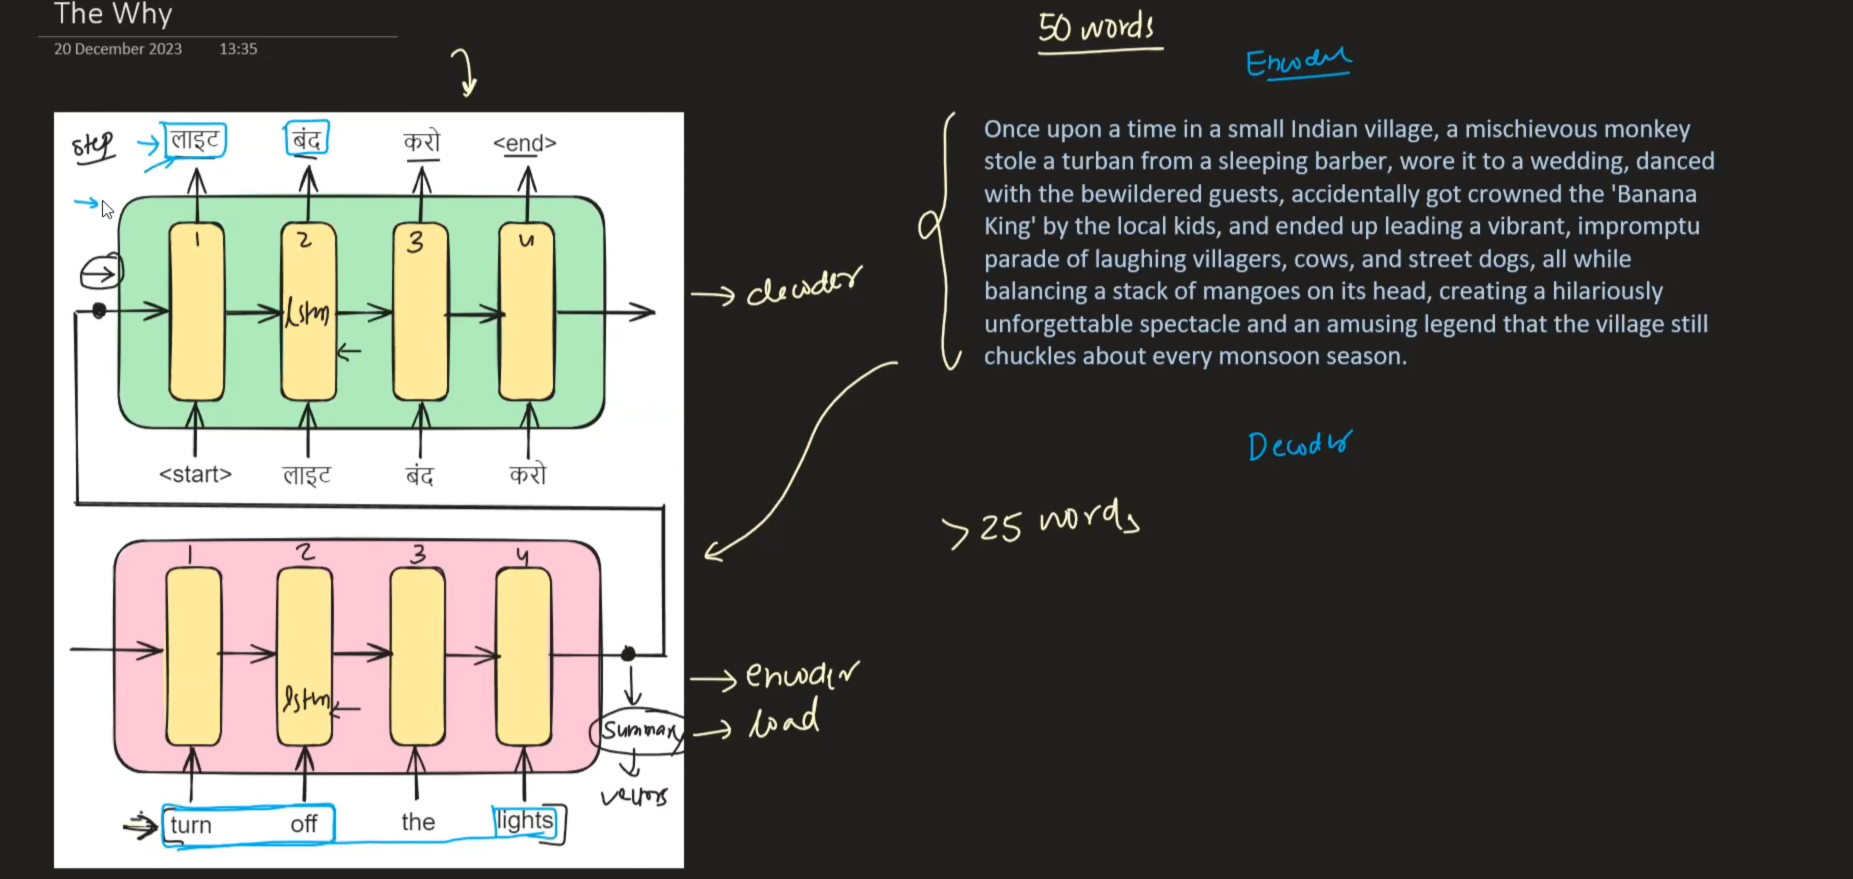

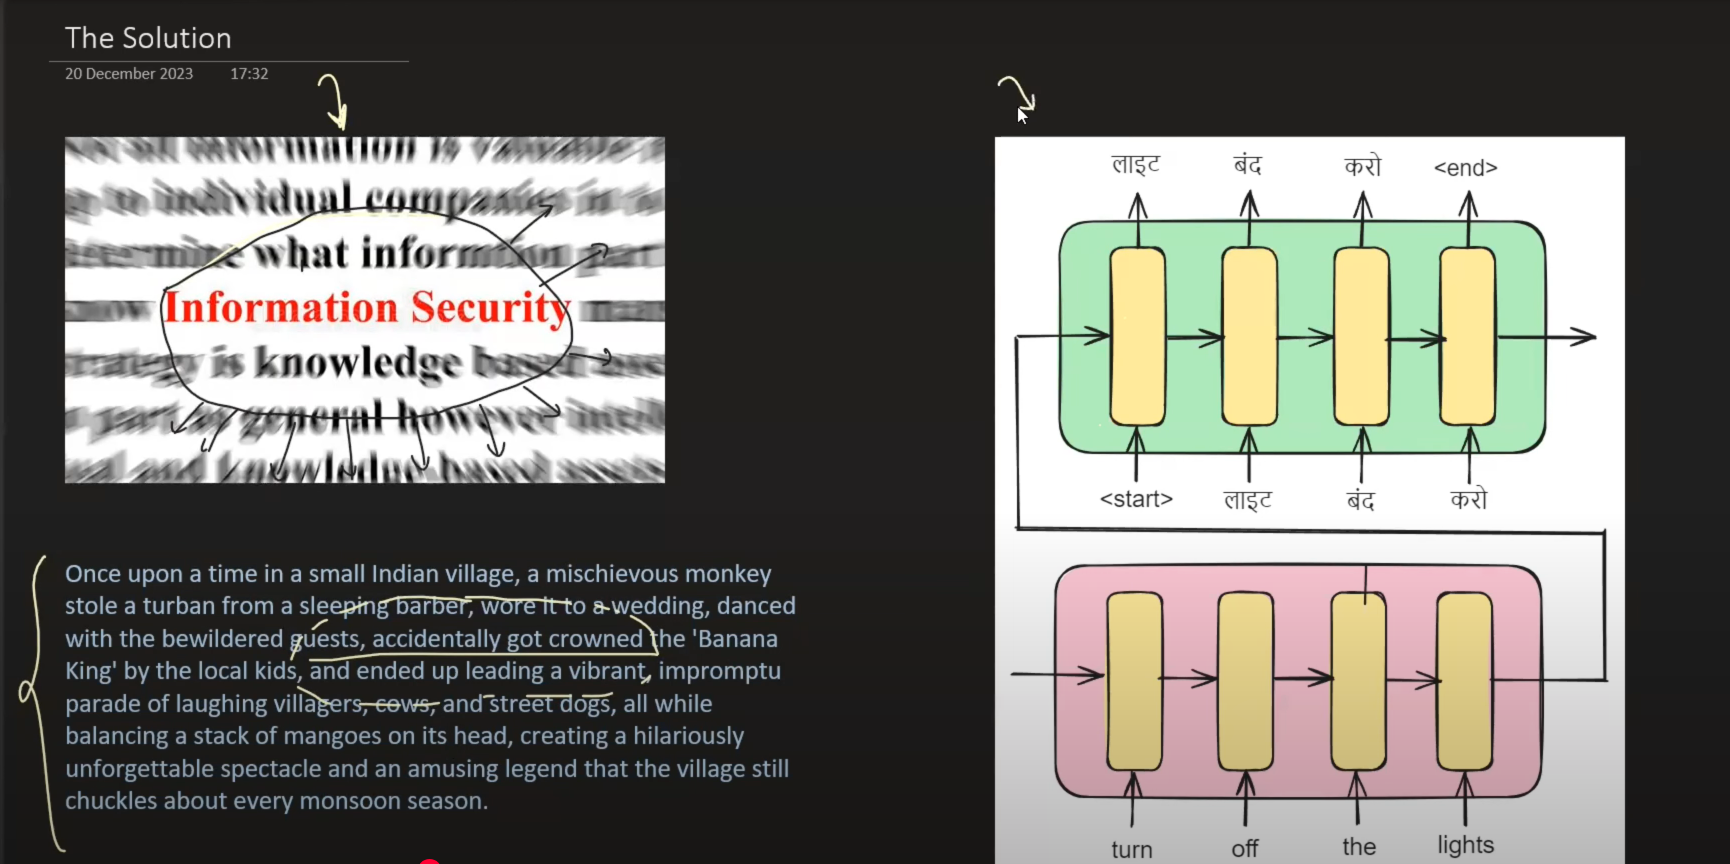

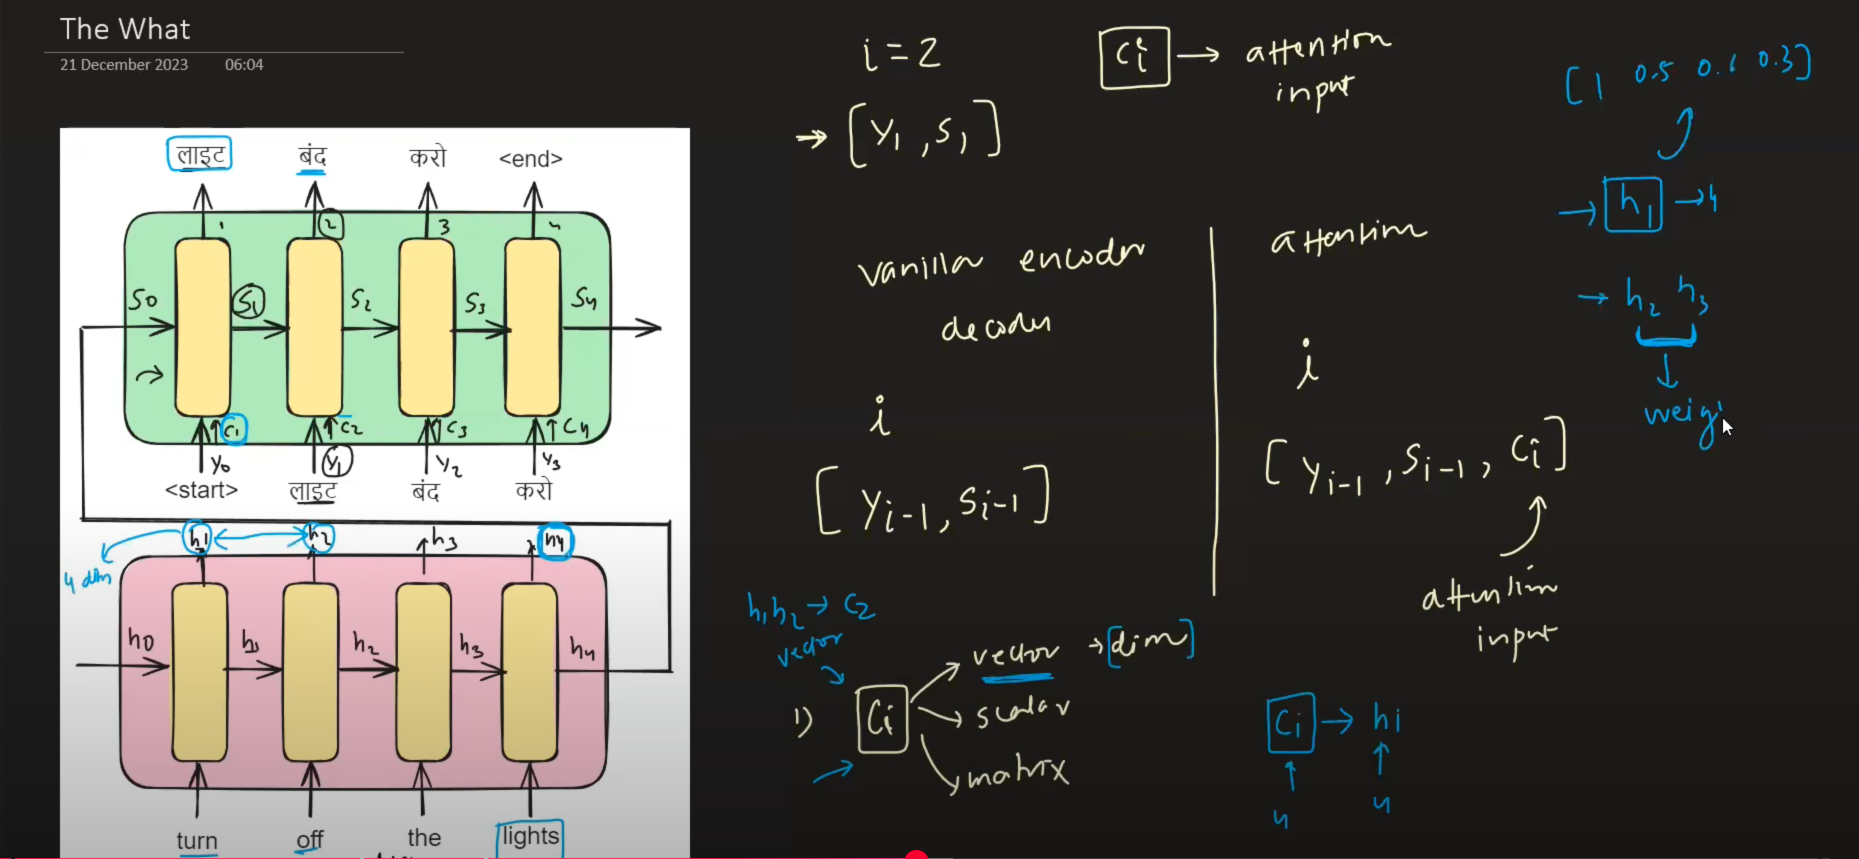

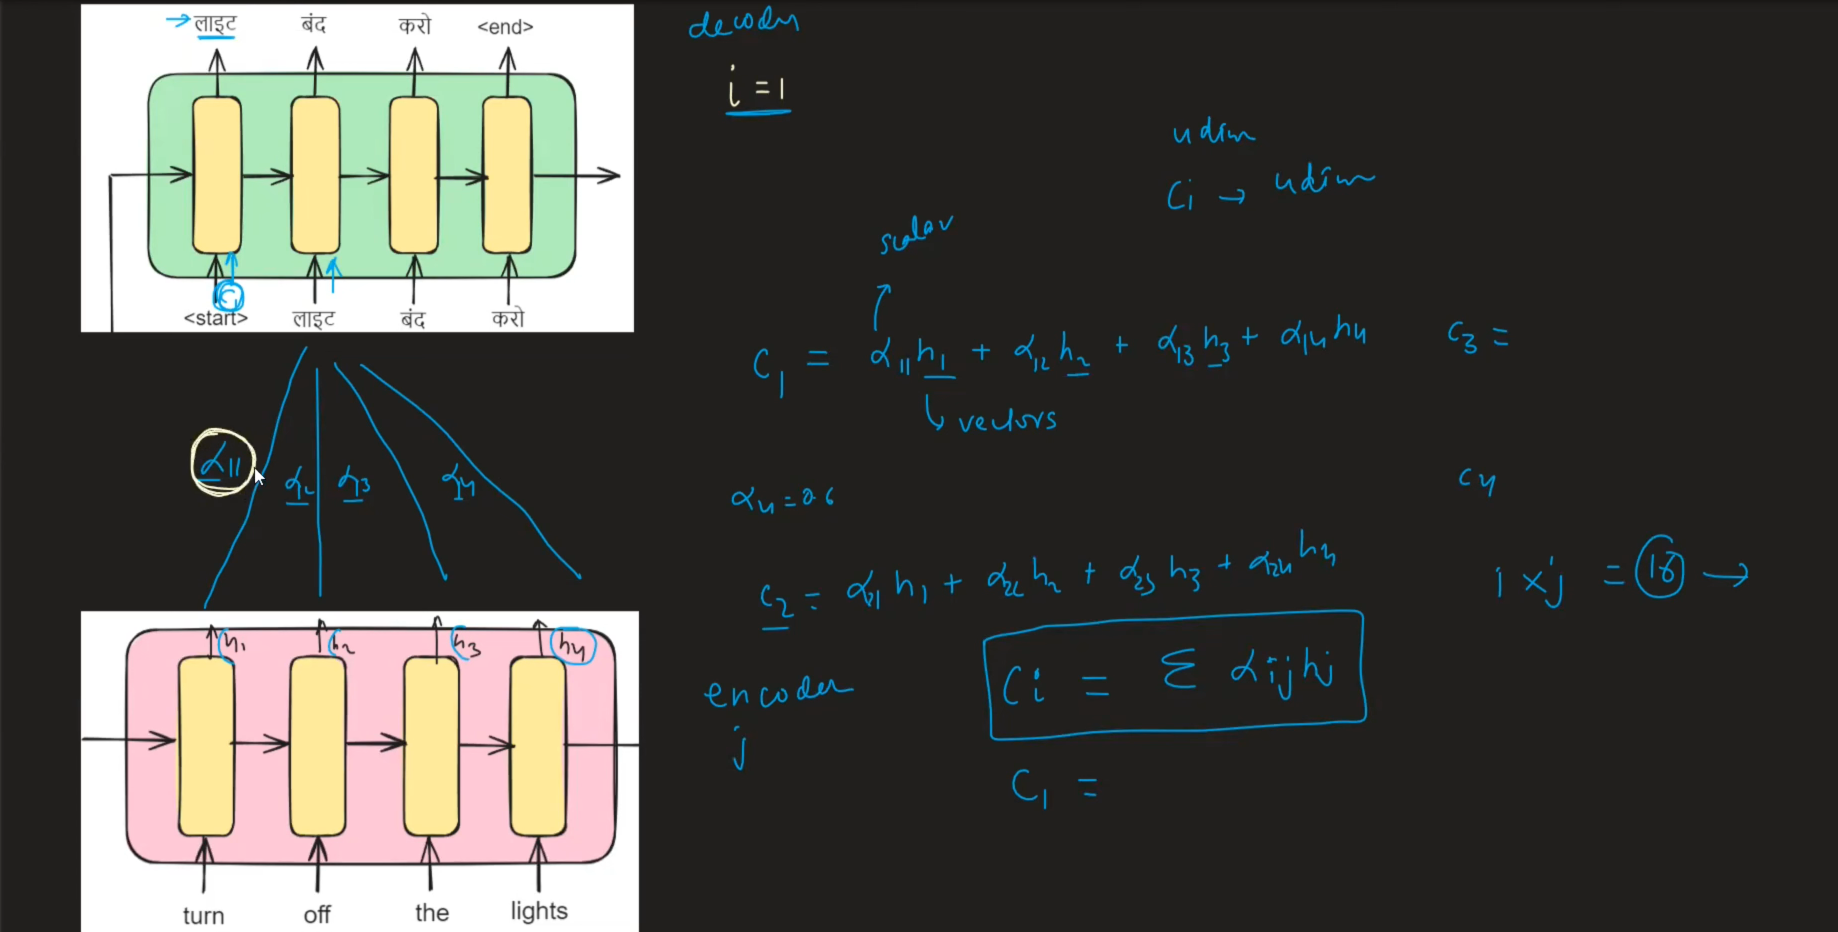

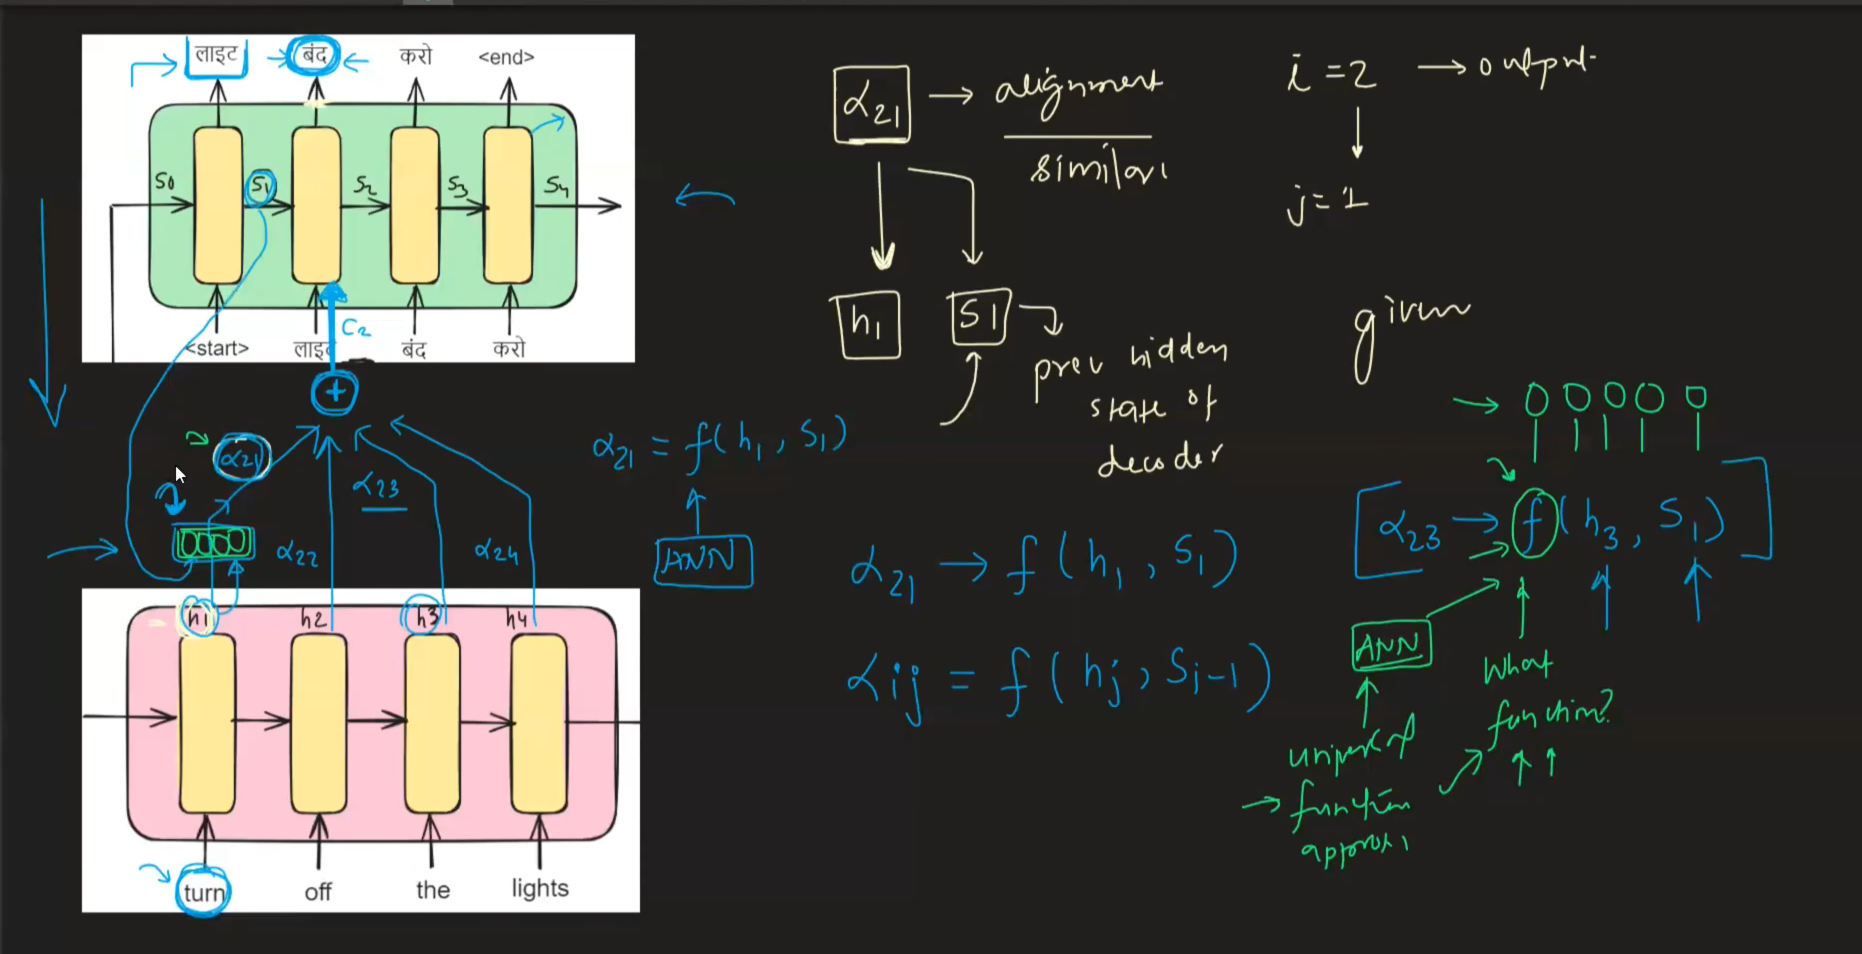

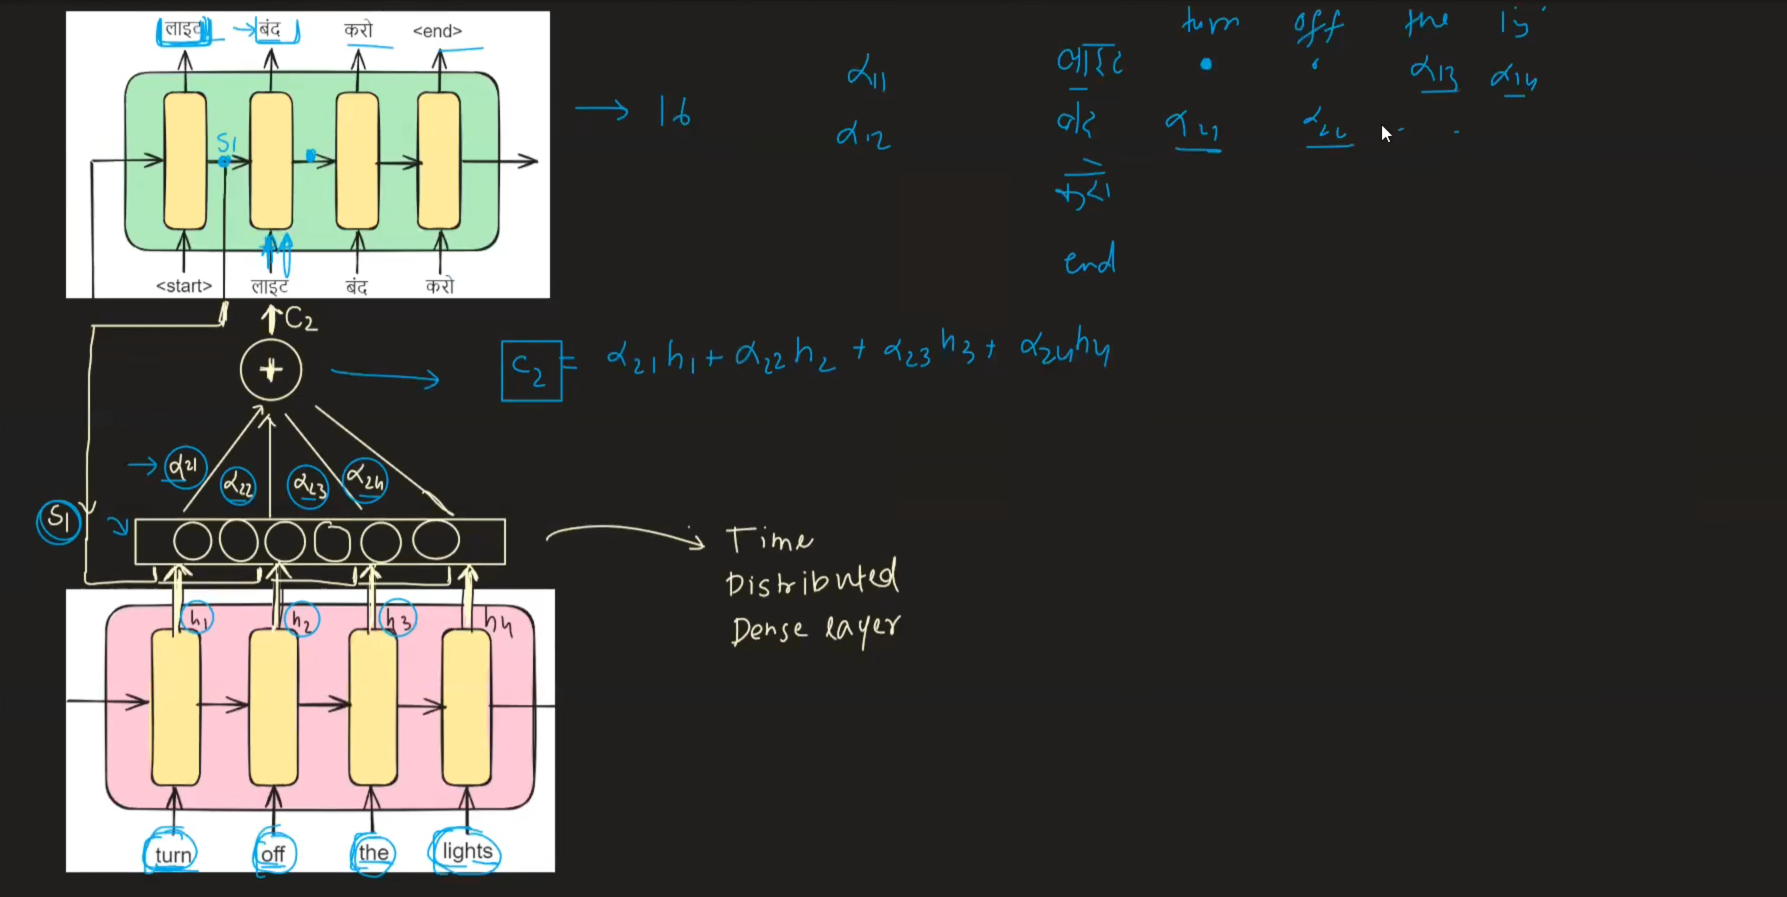

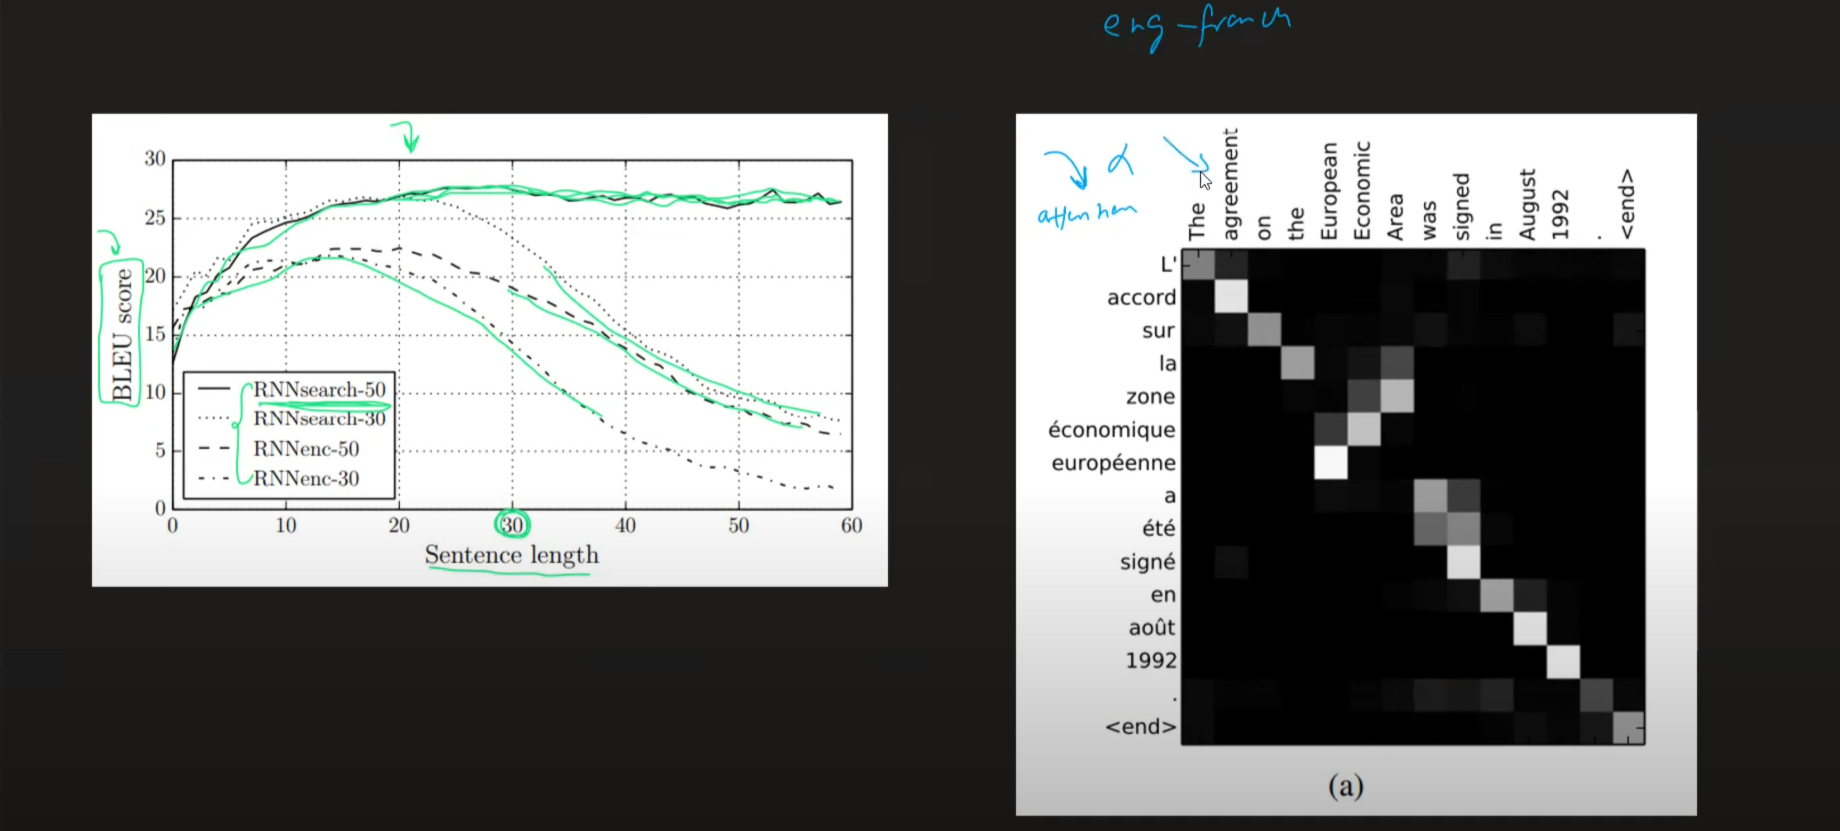


### **Why the Attention Mechanism is Needed**

The standard Encoder-Decoder architecture faces significant challenges, particularly with **long sentences**.

*   **Encoder Overload:** The encoder is forced to condense the entire input sentence into a **single, fixed-size summary vector**. This becomes highly inefficient and creates "too much load" when sentences exceed **25-30 words**, making it difficult to accurately represent all information, similar to a human struggling to remember and translate a very long sentence after reading it only once.
*   **Static Decoder Input:** The decoder receives this *same static summary vector* at every step of the translation process. However, to generate each output word, the decoder often only requires **specific words or parts of the input sentence**, not the entire summary. This static input hinders the decoder's ability to efficiently focus on relevant information.

### **What the Attention Mechanism Is**

The Attention Mechanism is a solution that allows the decoder to **dynamically focus** on relevant parts of the encoder's output, much like humans pay attention to specific regions of a text while translating.

### **How the Attention Mechanism Works**

The core idea is to provide the decoder with a **dynamic "attention input" (C_i)** at each time step:

*   **Third Input (C_i):** Unlike the vanilla Encoder-Decoder which uses two inputs (previous output `Y_i-1` and previous decoder hidden state `S_i-1`), the Attention-based model adds a third input, **C_i**, at every decoder time step.
*   **C_i as a Vector:** This attention input (C_i) is a **vector**. Its **dimension matches that of the encoder's hidden states (h_j)**.
*   **Weighted Sum of Encoder Hidden States:** C_i is calculated as a **weighted sum of all encoder hidden states (h_j)**. Each encoder hidden state (h_j) represents a specific part of the input sentence processed by the encoder.
*   **Alignment Weights (alpha_ij):** The "weights" in this sum are called **alignment scores** or **similarity scores (alpha_ij)**. These scalar values indicate **how important each encoder hidden state (h_j) is** for producing the current output word at decoder time step *i*. For example, `alpha_21` would show the importance of encoder's first hidden state (`h_1`) for the decoder's second output.
*   **Neural Network for Weights:** These crucial `alpha_ij` weights are calculated by a **small Artificial Neural Network (ANN)**. This ANN takes two inputs:
    1.  The **encoder's hidden state (h_j)** it's currently evaluating.
    2.  The **decoder's previous hidden state (s_i-1)**.
    The ANN learns to assess the relevance between these two states.
*   **End-to-End Training:** This small neural network is **trained alongside the main Encoder-Decoder architecture**. Its weights and biases are adjusted through backpropagation, making it an integral, learnable part of the entire model.

### **When and Why it's Beneficial**

*   **Improved Performance for Long Sentences:** The Attention Mechanism **significantly enhances translation quality**, especially for sentences **longer than 30 words**. While traditional models see their "Blue Score" (a measure of translation quality) drop sharply for longer inputs, attention-based models maintain a **stable or higher Blue Score**, demonstrating robust performance regardless of sentence length.
*   **Visual Interpretation:** A unique benefit is the ability to **visualize the attention weights (alphas)**. By plotting these weights, one can see exactly which input words the model "focused on" when generating each output word, empirically proving that the mechanism is working as intended. For example, when translating "European" into French, the model clearly gives the highest attention weight to the corresponding French word.
*   **Enhanced Context with Bi-directional LSTMs:** The original research paper further improved the encoder by using **Bi-directional LSTMs**. This allows the encoder to capture context from both preceding and succeeding words in the input sentence, further boosting translation quality, without changing the core attention calculation.


### **Overview: Neural Machine Translation and the "Attention" Problem**

*   **What is Neural Machine Translation (NMT)?** NMT is an approach that builds a **single neural network** to perform translation, aiming to maximize translation performance by learning jointly.
*   **The Standard Encoder-Decoder Model:** Most NMT models use an **encoder-decoder architecture**.
    *   An **encoder** network reads a source sentence and converts it into a **fixed-length vector**.
    *   A **decoder** then generates the translation from this encoded vector.
    *   The entire system is **jointly trained**.
*   **The Bottleneck (Why Attention is Needed):** The **fixed-length vector** is a major limitation, especially for **long sentences**.
    *   It forces the encoder to compress *all* necessary information from a source sentence into one static vector, which is difficult for long inputs.
    *   The **performance of basic encoder-decoders deteriorates rapidly** as input sentence length increases.

### **The Attention Mechanism (RNNsearch)**

The proposed model, called **RNNsearch**, extends the basic encoder-decoder to address this fixed-length vector issue by learning to **align and translate jointly**.

*   **Core Idea: Dynamic Focus**
    *   Instead of a single fixed-length vector, the model encodes the input into a **sequence of vectors (annotations)**.
    *   At each step of generating a target word, the decoder **(soft-)searches for relevant parts** of the source sentence's annotations.
    *   This "frees" the model from having to squash all information into one vector, allowing it to **cope better with long sentences**.

*   **How it Works: Detailed Steps**
    1.  **Encoder: Bidirectional RNN (BiRNN) for Annotations**:
        *   The encoder uses a **Bi-directional Recurrent Neural Network** to process the input sentence.
        *   A **forward RNN** reads the sentence from beginning to end, creating forward hidden states.
        *   A **backward RNN** reads the sentence in reverse, creating backward hidden states.
        *   An **annotation (h_j)** for each source word `x_j` is created by **concatenating** its forward and backward hidden states. This means `h_j` summarizes both **preceding and following words** around `x_j`.
    2.  **Decoder: Context Vector (c_i) with Attention**:
        *   For each target word `y_i` to be generated, the decoder receives a **distinct context vector (c_i)**.
        *   This `c_i` is a **weighted sum** of *all* the encoder's annotations (`h_1, ..., h_Tx`) [19, 79, Eq. 5].
        *   The **weights (`alpha_ij`)** determine how much attention (`hj`) is given to each source annotation `h_j` for producing `y_i` [19, 22, 79, Eq. 6].
    3.  **Alignment Model: Calculating Weights (`alpha_ij`)**:
        *   The `alpha_ij` weights are calculated using an **alignment model** [20, 79, Eq. 6].
        *   This model, a **feedforward neural network**, scores how well the encoder's annotation `h_j` matches the decoder's previous hidden state `s_i-1` (which represents the target words generated so far).
        *   Crucially, this alignment model is **jointly trained** with the rest of the NMT system, allowing gradients to flow through it. It computes a **"soft alignment"** instead of a rigid one.
    4.  **Recurrent Units:** The RNNs in both encoder and decoder use **gated hidden units**, similar to LSTMs, which help them learn and model **long-term dependencies** and prevent vanishing gradients.

### **Key Benefits and Results**

*   **Superior Performance for Long Sentences:**
    *   The RNNsearch model **significantly outperforms** the conventional RNNencdec.
    *   Its performance is **much more robust to sentence length**; while the basic RNNencdec's performance drops dramatically for long sentences, RNNsearch (e.g., RNNsearch-50) shows **no deterioration** even with sentences of 50 words or more.
    *   Even RNNsearch-30 (trained on shorter sentences) outperforms RNNencdec-50 (trained on longer sentences), highlighting its efficiency.
*   **Comparable to State-of-the-Art:** Achieves translation performance **comparable to conventional phrase-based systems** (like Moses), which often use more data and complex multi-component systems.
*   **Linguistically Plausible Alignments (Qualitative Analysis):**
    *   The model produces **intuitive (soft-)alignments** between source and target words.
    *   These alignments can be **visualized** (e.g., as heatmaps) to show which source words the model focused on for each target word [38, Fig. 3].
    *   It effectively handles **non-monotonic alignments** (e.g., reordering of adjectives and nouns between English and French) [39, 40, Fig. 3a].
    *   Soft-alignment allows the model to look at **multiple source words for context** (e.g., to translate "the" correctly in "the man" as "l'"), and naturally handles phrases of different lengths without needing "null" mappings.
*   **Improved Translation Quality for Long Inputs:** Qualitative examples show that RNNsearch-50 produces **accurate and complete translations** for long sentences where RNNencdec-50 starts deviating from the original meaning or making errors after approximately 30 words.

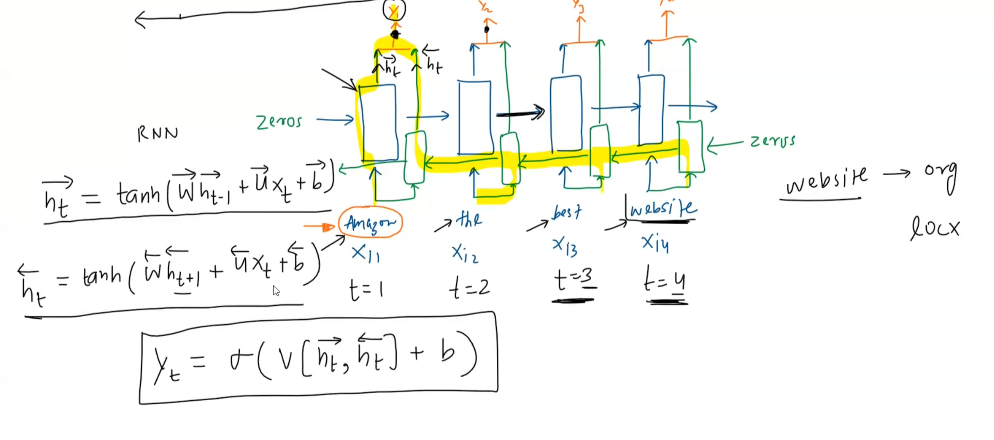


---

## 1. Vanilla Encoder–Decoder (a.k.a. Seq2Seq)

* **Architecture**: Two RNNs (or LSTMs/GRUs):

  * **Encoder**: Reads the input sequence step by step and compresses it into a **single fixed-size context vector** (the final hidden state).
  * **Decoder**: Uses this context vector as its initial state and generates the output sequence one token at a time.
* **Key property**:

  * The **entire input sequence is squeezed into one vector**.
  * Decoder has to rely only on this vector, regardless of how long or complex the input is.
* **Limitations**:

  * Works decently for short sequences.
  * Performance drops as input length grows, because the single context vector becomes a **bottleneck**.

---

## 2. Encoder–Decoder with Attention

* **Architecture**: Same encoder and decoder, but with an **attention mechanism** between them.

  * Encoder still produces hidden states for each input token (not just the final one).
  * At each decoding step, the decoder computes a **weighted combination** (attention) over *all* encoder hidden states.
  * The weights tell the model **which parts of the input to focus on** for generating the current output.

* **Key property**:

  * Instead of relying on one fixed vector, the decoder dynamically looks back at different parts of the input sequence during decoding.

* **Benefits**:

  * Handles long sentences much better.
  * Improves translation quality and alignment (e.g., in machine translation).
  * Provides interpretability (you can visualize which words the model "attends to").

---

## Intuition

* **Vanilla encoder–decoder**: Like trying to remember a whole paragraph and then retelling it from memory.
* **With attention**: Like being able to look back at the paragraph while retelling, focusing on the relevant parts.

---

✅ **Summary**:

* **Vanilla encoder–decoder** = fixed context vector → bottleneck.
* **With attention** = context is computed dynamically → better for long/complex sequences.

---


